# XGLUE4 — Kaggle Baseline Results

This research report imports the ten current Kaggle result archives, standardizes their metrics, and renders a publication-ready comparison table and F1 chart. It contains XGLUE4 results only.


In [1]:
from __future__ import annotations

import os
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "spectral_code").is_dir() and (candidate / "research").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the Spectral-Software repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RESULT_ARCHIVE_DIR = Path(os.getenv("KAGGLE_RESULTS_DIR", PROJECT_ROOT.parent / "outputs" / "kaggle")).resolve()
REPORT_DIR = PROJECT_ROOT / "research" / "latent_graph_learning" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_ORDER = ["AST", "CFG", "PDG", "DDG", "CPG"]
print("Kaggle result archives:", RESULT_ARCHIVE_DIR)
print("Research reports:", REPORT_DIR)


Kaggle result archives: C:\Users\koush\PyProjects\spectrals\outputs\kaggle
Research reports: C:\Users\koush\PyProjects\spectrals\Spectral-Software\research\latent_graph_learning\reports


In [2]:
# The archive/file mapping is explicit so one incorrect or missing export cannot be silently substituted.
RESULT_SPECS = [
    ("results (1).zip", "xglue4_latent_graph_results.csv", "Research latent graph", "Siamese Latent Graph (AST)", "single"),
    ("results (2).zip", "xglue4_fa_ast_ggnn_baseline_results.csv", "Graph learning", "FA-AST+GGNN", "single"),
    ("results (3).zip", "xglue4_rtvnn_baseline_results.csv", "Code representation", "RtvNN", "single"),
    ("results (4).zip", "xglue4_gnn_baseline_results.csv", "Graph learning", "GNN", "graph"),
    ("results (5).zip", "xglue4_deepsim_baseline_results.csv", "Code representation", "DeepSim", "single"),
    ("results (6).zip", "xglue4_deckard_baseline_results.csv", "Code representation", "Deckard", "single"),
    ("results (7).zip", "xglue4_snn_baseline_results.csv", "Spectral representation", "SNN", "graph"),
    ("results (8).zip", "xglue4_cdlh_baseline_results.csv", "Code representation", "CDLH", "single"),
    ("results (9).zip", "xglue4_astnn_baseline_results.csv", "Graph learning", "ASTNN", "single"),
    ("results.zip", "xglue4_fa_ast_gmn_baseline_results.csv", "Graph learning", "FA-AST+GMN", "single"),
]


def read_archived_csv(archive_name: str, csv_name: str) -> pd.DataFrame:
    archive_path = RESULT_ARCHIVE_DIR / archive_name
    if not archive_path.is_file():
        raise FileNotFoundError(f"Missing Kaggle archive: {archive_path}")
    with ZipFile(archive_path) as archive:
        if csv_name not in archive.namelist():
            raise FileNotFoundError(f"{csv_name} is absent from {archive_path.name}")
        return pd.read_csv(BytesIO(archive.read(csv_name)))


frames = []
for archive_name, csv_name, section, baseline, kind in RESULT_SPECS:
    frame = read_archived_csv(archive_name, csv_name).copy()
    frame.columns = [str(column).strip() for column in frame.columns]
    frame["Section"] = section
    frame["Baseline"] = baseline
    frame["SourceArchive"] = archive_name
    if kind == "graph":
        frame["Graph"] = frame["Method"].astype(str).str.upper()
        frame["DisplayMethod"] = baseline + " + " + frame["Graph"]
    else:
        frame["Graph"] = ""
        frame["DisplayMethod"] = baseline
    frames.append(frame)

raw_results = pd.concat(frames, ignore_index=True)
for column in ["P", "R", "F1", "Acc", "BestValidF1", "BestEpoch", "Threshold", "TrainPairs", "ValidPairs", "TestPairs"]:
    if column not in raw_results:
        raw_results[column] = pd.NA
    raw_results[column] = pd.to_numeric(raw_results[column], errors="coerce")

assert len(raw_results) == 18, f"Expected 18 result rows, found {len(raw_results)}"
assert set(raw_results.Dataset.dropna().astype(str).str.upper()) <= {"XGLUE4"}
raw_results[["Section", "DisplayMethod", "P", "R", "F1", "Acc", "BestValidF1"]]


,Section,DisplayMethod,P,R,F1,Acc,BestValidF1
0,Research latent graph,Siamese Latent Graph (AST),0.896017,0.846832,0.870730,0.965608,0.860598
1,Graph learning,FA-AST+GGNN,0.136779,1.000000,0.240642,0.136779,0.229466
2,Code representation,RtvNN,0.956714,0.892731,0.923616,0.979803,0.919428
3,Graph learning,GNN + AST,0.289070,0.431433,0.346187,0.777103,0.333961
4,Graph learning,GNN + CFG,0.259784,0.384829,0.310178,0.765878,0.314730
5,Graph learning,GNN + PDG,0.349390,0.415012,0.379384,0.814283,0.362434
6,Graph learning,GNN + DDG,0.301088,0.427807,0.353432,0.785906,0.357929
7,Graph learning,GNN + CPG,0.419923,0.484671,0.449980,0.837938,0.448129
8,Code representation,DeepSim,0.826017,0.751760,0.787141,0.944388,0.756472
9,Code representation,Deckard,0.154004,0.837786,0.260181,0.348326,0.248691


In [3]:
# Reformat the imported rows to match the paper-style grouped baseline table.
SECTION_ORDER = ["Our Method", "GNN Baselines", "Other Graph-based Learning Methods", "Spectral Representations Baselines"]
OTHER_METHOD_ORDER = {"Deckard": 0, "RtvNN": 1, "CDLH": 2, "DeepSim": 3, "ASTNN": 4, "FA-AST+GGNN": 5, "FA-AST+GMN": 6}

summary = raw_results.copy()
summary["Section"] = summary["Baseline"].map({
    "Siamese Latent Graph (AST)": "Our Method",
    "GNN": "GNN Baselines",
    "SNN": "Spectral Representations Baselines",
}).fillna("Other Graph-based Learning Methods")
summary["DisplayMethod"] = summary.apply(
    lambda row: row["Graph"] if row["Baseline"] == "GNN" else f"{row['Graph']} + SNN" if row["Baseline"] == "SNN" else row["Baseline"],
    axis=1,
)
summary["Section"] = pd.Categorical(summary["Section"], categories=SECTION_ORDER, ordered=True)
summary["MethodOrder"] = summary.apply(
    lambda row: GRAPH_ORDER.index(row["Graph"]) if row["Baseline"] in {"GNN", "SNN"} else OTHER_METHOD_ORDER.get(row["Baseline"], 0),
    axis=1,
)
summary = summary.sort_values(["Section", "MethodOrder"], kind="stable").reset_index(drop=True)

report_columns = ["Section", "DisplayMethod", "P", "R", "F1", "Acc", "BestValidF1", "BestEpoch", "Threshold", "TrainPairs", "ValidPairs", "TestPairs", "SourceArchive"]
report = summary[report_columns].rename(columns={"DisplayMethod": "Method", "BestValidF1": "ValidF1"})
report_path = REPORT_DIR / "xglue4_kaggle_baseline_results.csv"
report.to_csv(report_path, index=False)

display_df = report.drop(columns=["SourceArchive"]).copy()
for column in ["P", "R", "F1", "Acc", "ValidF1", "Threshold"]:
    display_df[column] = display_df[column].map(lambda value: f"{value:.4f}" if pd.notna(value) else "")
for column in ["BestEpoch", "TrainPairs", "ValidPairs", "TestPairs"]:
    display_df[column] = display_df[column].map(lambda value: f"{int(value):,}" if pd.notna(value) else "")
print("Saved standardized report:", report_path)
display(display_df)


Saved standardized report: C:\Users\koush\PyProjects\spectrals\Spectral-Software\research\latent_graph_learning\reports\xglue4_kaggle_baseline_results.csv


,Section,Method,P,R,F1,Acc,ValidF1,BestEpoch,Threshold,TrainPairs,ValidPairs,TestPairs
0,Research latent graph,Siamese Latent Graph (AST),0.8960,0.8468,0.8707,0.9656,0.8606,,0.9843,"901,028","415,416","415,416"
1,Graph learning,GNN + AST,0.2891,0.4314,0.3462,0.7771,0.3340,28,0.6177,"901,028",,"415,416"
2,Graph learning,GNN + CFG,0.2598,0.3848,0.3102,0.7659,0.3147,26,0.5723,"901,028",,"415,416"
3,Graph learning,GNN + PDG,0.3494,0.4150,0.3794,0.8143,0.3624,21,0.7051,"901,028",,"415,416"
4,Graph learning,GNN + DDG,0.3011,0.4278,0.3534,0.7859,0.3579,17,0.6377,"901,028",,"415,416"
5,Graph learning,GNN + CPG,0.4199,0.4847,0.4500,0.8379,0.4481,49,0.6675,"901,028",,"415,416"
6,Graph learning,ASTNN,0.7759,0.6234,0.6913,0.9239,0.7272,9,0.9379,"901,028","415,416","415,416"
7,Graph learning,FA-AST+GGNN,0.1368,1.0000,0.2406,0.1368,0.2295,1,0.4994,"901,028","415,416","415,416"
8,Graph learning,FA-AST+GMN,0.1368,1.0000,0.2406,0.1368,0.2295,1,0.5000,"901,028","415,416","415,416"
9,Code representation,CDLH,0.9420,0.9404,0.9412,0.9839,0.9518,1,0.9522,"901,028","415,416","415,416"


Saved F1 chart: C:\Users\koush\PyProjects\spectrals\Spectral-Software\research\latent_graph_learning\reports\xglue4_kaggle_baseline_f1.png


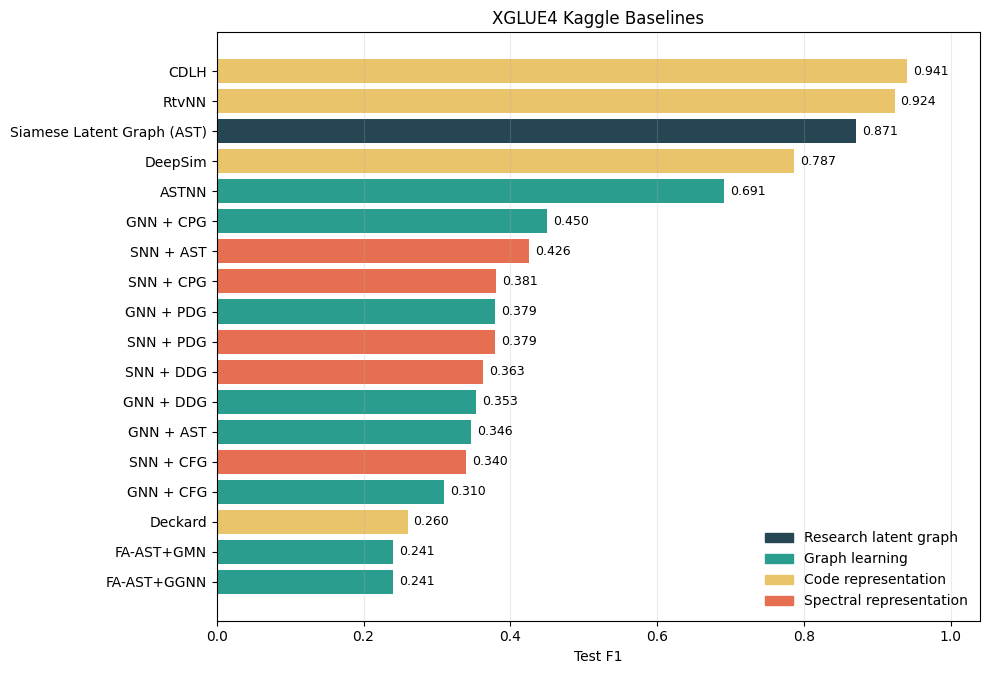

In [4]:
# Render a paper-style table with a merged category column, matching the requested layout.
import numpy as np
from matplotlib.patches import Rectangle

table_df = summary[["Section", "DisplayMethod", "P", "R", "F1", "Acc"]].copy()
for column in ["P", "R", "F1", "Acc"]:
    table_df[column] = table_df[column].map(lambda value: f"{value:.4f}" if pd.notna(value) else "")

section_labels = {
    "Our Method": "Our Method",
    "GNN Baselines": "GNN Baselines",
    "Other Graph-based Learning Methods": "Other Graph-based\nLearning Methods",
    "Spectral Representations Baselines": "Spectral Representations\nBaselines",
}
column_labels = ["", "Method", "P", "R", "F1", "Acc"]
column_widths = [3.25, 2.80, 1.02, 1.02, 1.02, 1.02]
x_edges = np.concatenate([[0.0], np.cumsum(column_widths)])
header_height, row_height = 0.52, 0.43
row_count = len(table_df)
total_height = header_height + row_count * row_height

fig, ax = plt.subplots(figsize=(9.3, max(7.2, 0.35 * row_count + 1.2)))
ax.set_xlim(0, float(x_edges[-1]))
ax.set_ylim(total_height, 0)
ax.axis("off")

for index, label in enumerate(column_labels):
    x0, x1 = x_edges[index], x_edges[index + 1]
    ax.add_patch(Rectangle((x0, 0), x1 - x0, header_height, facecolor="#f4f4f4", edgecolor="none"))
    ax.text((x0 + x1) / 2, header_height / 2, label, ha="center", va="center", fontsize=10.5, fontweight="bold")

for row_index in range(row_count):
    y0 = header_height + row_index * row_height
    face = "#ffffff" if row_index % 2 == 0 else "#fbfbfb"
    ax.add_patch(Rectangle((x_edges[1], y0), x_edges[-1] - x_edges[1], row_height, facecolor=face, edgecolor="none"))

section_spans = []
for section in SECTION_ORDER:
    indexes = np.flatnonzero(summary["Section"].astype(str).to_numpy() == section)
    if not len(indexes):
        continue
    start, end = int(indexes.min()), int(indexes.max()) + 1
    section_spans.append((section, start, end))
    y0, height = header_height + start * row_height, (end - start) * row_height
    ax.add_patch(Rectangle((0, y0), x_edges[1], height, facecolor="#fafafa", edgecolor="none"))
    ax.text(x_edges[1] / 2, y0 + height / 2, section_labels[section], ha="center", va="center", fontsize=9.5, fontweight="bold", linespacing=1.08)

for row_index, row in table_df.iterrows():
    y = header_height + row_index * row_height + row_height / 2
    ax.text(x_edges[1] + 0.18, y, row["DisplayMethod"], ha="left", va="center", fontsize=9.6)
    for column_index, column in enumerate(["P", "R", "F1", "Acc"], start=2):
        ax.text((x_edges[column_index] + x_edges[column_index + 1]) / 2, y, row[column], ha="center", va="center", fontsize=9.3)

for x in x_edges:
    ax.plot([x, x], [0, total_height], color="#222222", linewidth=0.9 if x in {x_edges[0], x_edges[1], x_edges[-1]} else 0.55)
ax.plot([0, x_edges[-1]], [0, 0], color="#222222", linewidth=1.1)
ax.plot([0, x_edges[-1]], [header_height, header_height], color="#222222", linewidth=1.0)
ax.plot([0, x_edges[-1]], [total_height, total_height], color="#222222", linewidth=1.1)
for row_index in range(1, row_count):
    y = header_height + row_index * row_height
    ax.plot([x_edges[1], x_edges[-1]], [y, y], color="#777777", linewidth=0.32)
for _, start, end in section_spans:
    for index in (start, end):
        y = header_height + index * row_height
        ax.plot([0, x_edges[-1]], [y, y], color="#222222", linewidth=0.95)

fig.tight_layout(pad=0.25)
figure_path = REPORT_DIR / "xglue4_kaggle_baseline_table.png"
fig.savefig(figure_path, dpi=240, bbox_inches="tight", facecolor="white")
print("Saved paper-style table:", figure_path)
plt.show()
